# A2.1 Regresión logística y validación cruzada

**Materia:** Inteligencia Artificial  
**Alumno:** Emiliano Pascual Pinales Sánchez  
**Matrícula:** 657657  

## 1. Introducción

En el proyecto anterior se analizaron datos de la Encuesta Nacional de Ingresos y Gastos de los Hogares 2024 (ENIGH), elaborada por el INEGI, con el objetivo de estimar el gasto corriente monetario de los hogares mexicanos mediante modelos de regresión.

En esta actividad se transforma el problema original de regresión en un problema de clasificación. El objetivo será determinar si las características económicas, demográficas y del hogar permiten clasificar a un hogar según presente un nivel de gasto corriente monetario bajo o alto.

Para ello se construirá una variable de salida binaria a partir del gasto corriente monetario, se entrenará un modelo de regresión logística y se evaluará su desempeño mediante validación cruzada y un conjunto de prueba independiente. También se analizarán distintas métricas de clasificación, diferentes umbrales de decisión, la curva ROC, el AUC y los coeficientes del modelo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "concentradohogar.csv",
    dtype={
        "folioviv": str,
        "foliohog": str,
        "ubica_geo": str,
        "est_dis": str,
        "upm": str
    },
    low_memory=False
)

print("Base de datos cargada correctamente.")
print("Número de hogares:", df.shape[0])
print("Número de variables:", df.shape[1])

Base de datos cargada correctamente.
Número de hogares: 91414
Número de variables: 126


## 2. Definición del problema de clasificación

En el proyecto anterior, la variable de respuesta `gasto_mon` representó el gasto corriente monetario trimestral del hogar como una variable cuantitativa continua.

Para transformar el problema en uno de clasificación binaria, se utilizará la mediana del gasto corriente monetario como punto de corte. Los hogares con un gasto igual o menor a la mediana serán clasificados como gasto bajo (0), mientras que los hogares con un gasto superior a la mediana serán clasificados como gasto alto (1).

El uso de la mediana permite establecer un criterio basado directamente en la distribución observada de los datos y ayuda a obtener clases aproximadamente equilibradas, lo cual facilita la evaluación del modelo y evita que una clase tenga una representación considerablemente mayor que la otra.

In [3]:
df = df.copy()

mediana_gasto = df["gasto_mon"].median()

df["gasto_alto"] = (df["gasto_mon"] > mediana_gasto).astype(int)

balance_clases = pd.DataFrame({
    "Frecuencia": df["gasto_alto"].value_counts().sort_index(),
    "Porcentaje": df["gasto_alto"].value_counts(
        normalize=True
    ).sort_index() * 100
})

balance_clases.index = ["Gasto bajo (0)", "Gasto alto (1)"]

print(f"Mediana del gasto: ${mediana_gasto:,.2f}")
balance_clases

Mediana del gasto: $34,182.51


,Frecuencia,Porcentaje
Gasto bajo (0),45707,50.0
Gasto alto (1),45707,50.0


## 3. Preparación de los datos y separación entrenamiento-prueba

Se utilizarán como variables explicativas características económicas, demográficas y del hogar que ya fueron consideradas en el proyecto anterior y que no corresponden directamente al gasto utilizado para construir la variable de salida.

Las variables numéricas consideradas son el ingreso corriente, número de integrantes, número de personas ocupadas, número de perceptores de ingreso y edad del jefe del hogar. El ingreso se transformará mediante logaritmo debido a su elevada asimetría observada en el análisis anterior.

También se utilizarán como variables categóricas la educación y sexo del jefe del hogar, el tamaño de localidad, el estrato socioeconómico y la clase de hogar.

El conjunto de datos se dividirá en 80 % para entrenamiento y 20 % para prueba. La división será estratificada para conservar la misma proporción de las clases en ambos subconjuntos.

In [4]:
from sklearn.model_selection import train_test_split

df["ingreso_log"] = np.log1p(df["ing_cor"])

variables_modelo = [
    "ingreso_log",
    "tot_integ",
    "ocupados",
    "percep_ing",
    "edad_jefe",
    "educa_jefe",
    "sexo_jefe",
    "tam_loc",
    "est_socio",
    "clase_hog"
]

X = df[variables_modelo].copy()
y = df["gasto_alto"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (73131, 10)
Prueba: (18283, 10)


### 3.1 Balance de clases después de la separación

Debido a que la proporción de las clases puede afectar la evaluación de un modelo de clasificación, se verificará el porcentaje de hogares con gasto bajo y gasto alto en el conjunto original, en el conjunto de entrenamiento y en el conjunto de prueba.

La división estratificada permite conservar prácticamente la misma distribución de clases en los tres conjuntos, evitando que las diferencias de desempeño sean consecuencia de una partición desbalanceada.

In [5]:
def obtener_balance(y):
    return [
        (y == 0).sum(),
        (y == 1).sum(),
        (y == 0).mean() * 100,
        (y == 1).mean() * 100
    ]

balance = pd.DataFrame(
    [
        obtener_balance(y),
        obtener_balance(y_train),
        obtener_balance(y_test)
    ],
    index=["Datos originales", "Entrenamiento", "Prueba"],
    columns=[
        "Gasto bajo",
        "Gasto alto",
        "% gasto bajo",
        "% gasto alto"
    ]
)

balance.round(2)

,Gasto bajo,Gasto alto,% gasto bajo,% gasto alto
Datos originales,45707,45707,50.0,50.0
Entrenamiento,36565,36566,50.0,50.0
Prueba,9142,9141,50.0,50.0


## 4. Metodología de regresión logística

La regresión logística se utilizará como modelo de clasificación binaria para estimar la probabilidad de que un hogar pertenezca a la clase de gasto alto.

Las variables numéricas serán estandarizadas para que las diferencias de escala no afecten el ajuste del modelo. Las variables categóricas serán transformadas mediante codificación one-hot, utilizando una categoría como referencia.

Todo el preprocesamiento se incluirá dentro de un pipeline. Esto permite que las transformaciones se ajusten únicamente con los datos correspondientes a cada conjunto de entrenamiento durante la validación cruzada y evita utilizar información externa al proceso de entrenamiento.

El desempeño se estimará mediante validación cruzada estratificada de 5 particiones utilizando exclusivamente el conjunto de entrenamiento. Se evaluarán accuracy, precision, recall, F1-score y ROC-AUC.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

variables_numericas = [
    "ingreso_log",
    "tot_integ",
    "ocupados",
    "percep_ing",
    "edad_jefe"
]

variables_categoricas = [
    "educa_jefe",
    "sexo_jefe",
    "tam_loc",
    "est_socio",
    "clase_hog"
]

preprocesamiento = ColumnTransformer([
    (
        "numericas",
        StandardScaler(),
        variables_numericas
    ),
    (
        "categoricas",
        OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ),
        variables_categoricas
    )
])

pipeline = Pipeline([
    ("preprocesamiento", preprocesamiento),
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

resultados_cv = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas
)

resumen_cv = pd.DataFrame({
    metrica: resultados_cv[f"test_{metrica}"]
    for metrica in metricas
})

resumen_cv

,accuracy,precision,recall,f1,roc_auc
0,0.792780,0.794851,0.789308,0.792070,0.874031
1,0.782511,0.781779,0.783810,0.782793,0.868968
2,0.785177,0.781330,0.792014,0.786636,0.866824
3,0.786271,0.781574,0.794612,0.788039,0.867528
4,0.787570,0.785423,0.791331,0.788366,0.870738


In [7]:
promedios_cv = resumen_cv.mean()
desviaciones_cv = resumen_cv.std()

resumen_metricas_cv = pd.DataFrame({
    "Promedio": promedios_cv,
    "Desviación estándar": desviaciones_cv
})

resumen_metricas_cv.round(4)

,Promedio,Desviación estándar
accuracy,0.7869,0.0038
precision,0.7850,0.0058
recall,0.7902,0.0041
f1,0.7876,0.0033
roc_auc,0.8696,0.0029


### 4.1 Resultados de la validación cruzada

La validación cruzada estratificada de 5 particiones mostró un desempeño estable entre los distintos subconjuntos de validación. El modelo obtuvo un accuracy promedio cercano a 0.787, lo que indica que clasificó correctamente aproximadamente el 78.7 % de los hogares.

La precision promedio fue cercana a 0.785 y el recall a 0.790. Esto indica que el modelo mantiene un desempeño similar tanto al identificar correctamente hogares clasificados con gasto alto como al recuperar una proporción importante de los hogares que realmente pertenecen a esta clase. El F1-score promedio fue aproximadamente 0.788, reflejando un equilibrio entre precision y recall.

El ROC-AUC promedio fue aproximadamente 0.870, lo que muestra una buena capacidad del modelo para distinguir entre hogares con gasto bajo y gasto alto.

Las desviaciones estándar fueron pequeñas en todas las métricas, por lo que el desempeño fue consistente entre las cinco particiones. Esto hace que la validación cruzada proporcione una estimación más robusta del comportamiento esperado del modelo que la obtenida a partir de una sola división de los datos.

## 5. Entrenamiento final y evaluación en el conjunto de prueba

Después de estimar el desempeño mediante validación cruzada, se entrenará el modelo de regresión logística utilizando la totalidad del conjunto de entrenamiento.

El conjunto de prueba, que no participó en el ajuste del modelo ni en la validación cruzada, se utilizará para evaluar el desempeño final con observaciones independientes.

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

metricas_prueba = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Valor": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

metricas_prueba.round(4)

,Métrica,Valor
0,Accuracy,0.7805
1,Precision,0.7787
2,Recall,0.7836
3,F1-score,0.7811
4,ROC-AUC,0.8665


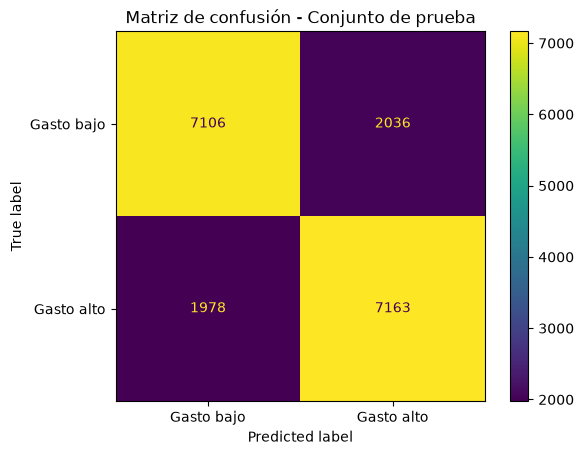

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

matriz = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Gasto bajo", "Gasto alto"]
)

disp.plot()
plt.title("Matriz de confusión - Conjunto de prueba")
plt.show()

### 5.1 Resultados en el conjunto de prueba

Utilizando el umbral de decisión estándar de 0.50, el modelo obtuvo un accuracy de 0.7805, lo que indica que clasificó correctamente aproximadamente el 78.1 % de los hogares del conjunto de prueba.

La precision fue de 0.7787 y el recall de 0.7836, mientras que el F1-score alcanzó 0.7811. Estos resultados muestran un desempeño relativamente equilibrado al identificar hogares con gasto alto.

La matriz de confusión muestra 7,106 hogares con gasto bajo correctamente clasificados y 7,163 hogares con gasto alto correctamente identificados. Por otra parte, 2,036 hogares con gasto bajo fueron clasificados como gasto alto y 1,978 hogares con gasto alto fueron clasificados como gasto bajo.

El ROC-AUC obtenido fue de 0.8665, lo que indica que el modelo presenta una buena capacidad para discriminar entre hogares con gasto bajo y gasto alto.

In [10]:
comparacion = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Validación cruzada": [
        promedios_cv["accuracy"],
        promedios_cv["precision"],
        promedios_cv["recall"],
        promedios_cv["f1"],
        promedios_cv["roc_auc"]
    ],
    "Prueba": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

comparacion["Diferencia absoluta"] = abs(
    comparacion["Validación cruzada"] - comparacion["Prueba"]
)

comparacion.round(4)

,Métrica,Validación cruzada,Prueba,Diferencia absoluta
0,Accuracy,0.7869,0.7805,0.0064
1,Precision,0.7850,0.7787,0.0063
2,Recall,0.7902,0.7836,0.0066
3,F1-score,0.7876,0.7811,0.0064
4,ROC-AUC,0.8696,0.8665,0.0031


### 5.2 Comparación entre validación cruzada y prueba

Los resultados obtenidos en el conjunto de prueba son muy cercanos a los promedios estimados mediante validación cruzada.

Las diferencias absolutas son inferiores a 0.01 en todas las métricas. El accuracy disminuyó aproximadamente 0.0064, la precision 0.0063, el recall 0.0066 y el F1-score 0.0064. En el caso del ROC-AUC, la diferencia fue de aproximadamente 0.0031.

Esta consistencia indica que la validación cruzada proporcionó una estimación adecuada del desempeño esperado del modelo. Además, el comportamiento similar en datos de prueba independientes sugiere que el modelo mantiene una capacidad de generalización estable.

In [11]:
umbrales = [0.30, 0.40, 0.50, 0.60, 0.70]

resultados_umbrales = []

for umbral in umbrales:
    pred_umbral = (y_prob >= umbral).astype(int)

    resultados_umbrales.append({
        "Umbral": umbral,
        "Accuracy": accuracy_score(y_test, pred_umbral),
        "Precision": precision_score(
            y_test,
            pred_umbral,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred_umbral,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            pred_umbral,
            zero_division=0
        )
    })

tabla_umbrales = pd.DataFrame(resultados_umbrales)

tabla_umbrales.round(4)

,Umbral,Accuracy,Precision,Recall,F1-score
0,0.3,0.7521,0.6909,0.9123,0.7863
1,0.4,0.7755,0.7379,0.8544,0.7919
2,0.5,0.7805,0.7787,0.7836,0.7811
3,0.6,0.7720,0.8223,0.6940,0.7527
4,0.7,0.7498,0.8689,0.5882,0.7015


### 5.3 Análisis de distintos umbrales de decisión

El umbral de decisión modifica el equilibrio entre precision y recall. Con un umbral de 0.30, el recall alcanza 0.9123, por lo que el modelo identifica una proporción muy alta de los hogares con gasto alto. Sin embargo, la precision disminuye a 0.6909, lo que implica una mayor cantidad de falsos positivos.

Al aumentar el umbral, la precision mejora mientras que el recall disminuye. Con un umbral de 0.70, la precision alcanza 0.8689, pero el recall cae a 0.5882, por lo que el modelo se vuelve más estricto para clasificar un hogar como gasto alto.

El umbral de 0.40 presentó el mayor F1-score, con 0.7919, mientras que el umbral estándar de 0.50 presentó el mayor accuracy, con 0.7805, y mantuvo un equilibrio adecuado entre precision y recall.

Por lo tanto, la elección del umbral depende del objetivo del problema. Si fuera más importante detectar la mayor cantidad posible de hogares con gasto alto podría utilizarse un umbral menor. En cambio, si se buscara reducir los falsos positivos sería conveniente utilizar un umbral mayor.

## 6. Curva ROC y AUC

La curva ROC permite evaluar la capacidad discriminativa del modelo considerando todos los posibles umbrales de decisión. Esta curva representa la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos.

El área bajo la curva (AUC) resume esta capacidad de discriminación en un solo valor. Un valor cercano a 0.50 representa un desempeño similar al azar, mientras que valores mayores indican una mayor capacidad para distinguir entre las clases.

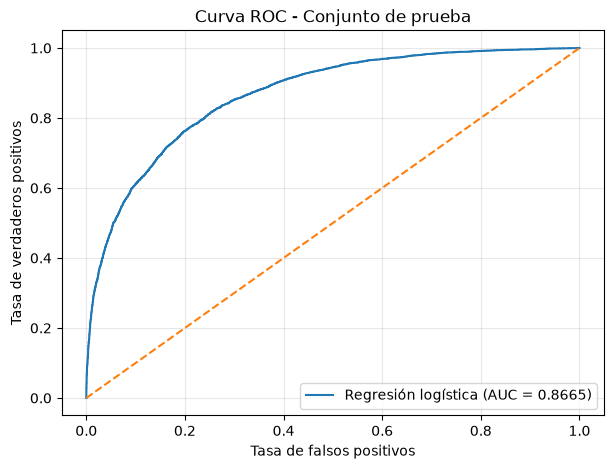

AUC: 0.8665


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_prueba = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Regresión logística (AUC = {auc_prueba:.4f})"
)
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC - Conjunto de prueba")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC: {auc_prueba:.4f}")

### 6.1 Interpretación de la curva ROC

El modelo obtuvo un AUC de 0.8665 en el conjunto de prueba. Este resultado indica una buena capacidad para diferenciar entre hogares con gasto bajo y hogares con gasto alto.

Además, el valor es muy cercano al ROC-AUC promedio de 0.8696 obtenido mediante validación cruzada, lo que refuerza la consistencia del desempeño del modelo en datos independientes.

## 7. Interpretación del modelo

Los coeficientes de la regresión logística permiten analizar cómo las variables utilizadas se relacionan con la probabilidad de que un hogar pertenezca a la clase de gasto alto.

Un coeficiente positivo indica una asociación con una mayor probabilidad de pertenecer a la clase de gasto alto, mientras que un coeficiente negativo indica una asociación en sentido contrario. La magnitud absoluta del coeficiente permite comparar la intensidad relativa de los efectos dentro del modelo.

In [13]:
nombres_variables = (
    pipeline
    .named_steps["preprocesamiento"]
    .get_feature_names_out()
)

coeficientes = pipeline.named_steps["modelo"].coef_[0]

tabla_coeficientes = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coeficientes,
    "Odds ratio": np.exp(coeficientes)
})

tabla_coeficientes["Magnitud"] = abs(
    tabla_coeficientes["Coeficiente"]
)

tabla_coeficientes = (
    tabla_coeficientes
    .sort_values("Magnitud", ascending=False)
    .drop(columns="Magnitud")
    .reset_index(drop=True)
)

tabla_coeficientes.round(4)

,Variable,Coeficiente,Odds ratio
0,categoricas__educa_jefe_11,1.7017,5.4835
1,numericas__ingreso_log,1.5818,4.8639
2,categoricas__educa_jefe_10,1.2536,3.5030
3,categoricas__educa_jefe_9,1.0190,2.7703
4,categoricas__educa_jefe_8,0.7511,2.1193
5,categoricas__educa_jefe_7,0.6156,1.8507
6,categoricas__est_socio_4,0.5131,1.6705
7,categoricas__educa_jefe_6,0.4015,1.4941
8,categoricas__est_socio_3,0.3904,1.4775
9,categoricas__educa_jefe_5,0.3444,1.4111


### 7.1 Interpretación de los coeficientes

Los coeficientes muestran que el ingreso y algunas características educativas y socioeconómicas tienen una asociación importante con la probabilidad de que un hogar pertenezca a la clase de gasto alto.

Entre las variables con mayor efecto positivo se encuentra `ingreso_log`, con un coeficiente de 1.5818 y un odds ratio de 4.8639. Debido a que las variables numéricas fueron estandarizadas, este resultado indica que un aumento de una desviación estándar en el ingreso corriente transformado se asocia con un incremento importante en las posibilidades de pertenecer a la clase de gasto alto, manteniendo constantes las demás variables.

En las variables categóricas, `educa_jefe_11` presentó el coeficiente positivo de mayor magnitud, con 1.7017 y un odds ratio de 5.4835 respecto a la categoría de referencia de educación. También destacan `educa_jefe_10`, `educa_jefe_9` y `educa_jefe_8`, todas con coeficientes positivos. En general, estas categorías muestran una mayor asociación con la clase de gasto alto respecto a la categoría de educación utilizada como referencia.

El estrato socioeconómico también presenta una relación positiva. `est_socio_4` obtuvo un coeficiente de 0.5131, mientras que `est_socio_3` y `est_socio_2` también presentaron coeficientes positivos. Esto indica que estas categorías tienen mayores posibilidades de pertenecer a la clase de gasto alto que la categoría de referencia.

El número de integrantes del hogar presentó un coeficiente positivo de 0.3228, indicando que mayores valores de esta característica se asocian con una mayor probabilidad de gasto alto. Las variables `ocupados` y `percep_ing` también mostraron coeficientes positivos, aunque de menor magnitud relativa.

Entre los efectos negativos se encuentran `tam_loc_4`, con un coeficiente de -0.2466, `edad_jefe`, con -0.1469, y `sexo_jefe_2`, con -0.0960. Estos resultados indican una asociación con una menor probabilidad de pertenecer a la clase de gasto alto respecto a sus correspondientes valores o categorías de referencia, manteniendo constantes las demás características.

Los coeficientes deben interpretarse como asociaciones dentro del modelo y no como relaciones causales. En conjunto, los resultados son coherentes con la problemática original, ya que el ingreso y distintas características socioeconómicas presentan algunas de las asociaciones de mayor magnitud con el nivel de gasto de los hogares.

In [14]:
tabla_interpretacion = tabla_coeficientes.copy()

tabla_interpretacion["Dirección"] = np.where(
    tabla_interpretacion["Coeficiente"] > 0,
    "Positiva",
    "Negativa"
)

tabla_interpretacion.round(4)

,Variable,Coeficiente,Odds ratio,Dirección
0,categoricas__educa_jefe_11,1.7017,5.4835,Positiva
1,numericas__ingreso_log,1.5818,4.8639,Positiva
2,categoricas__educa_jefe_10,1.2536,3.5030,Positiva
3,categoricas__educa_jefe_9,1.0190,2.7703,Positiva
4,categoricas__educa_jefe_8,0.7511,2.1193,Positiva
5,categoricas__educa_jefe_7,0.6156,1.8507,Positiva
6,categoricas__est_socio_4,0.5131,1.6705,Positiva
7,categoricas__educa_jefe_6,0.4015,1.4941,Positiva
8,categoricas__est_socio_3,0.3904,1.4775,Positiva
9,categoricas__educa_jefe_5,0.3444,1.4111,Positiva


## 8. Conclusiones

En esta actividad se transformó el problema original de predicción del gasto corriente monetario de los hogares mexicanos en un problema de clasificación binaria utilizando información de la ENIGH 2024.

La mediana del gasto corriente monetario se utilizó como punto de corte para definir las clases de gasto bajo y gasto alto. Este criterio produjo dos clases completamente equilibradas, con 50 % de las observaciones en cada una. La división estratificada permitió conservar prácticamente esta misma proporción en los conjuntos de entrenamiento y prueba.

La regresión logística presentó un desempeño consistente. Mediante validación cruzada estratificada de cinco particiones obtuvo un accuracy promedio de 0.7869, un F1-score de 0.7876 y un ROC-AUC de 0.8696. En el conjunto de prueba independiente se obtuvo un accuracy de 0.7805, un F1-score de 0.7811 y un ROC-AUC de 0.8665.

Las pequeñas diferencias entre validación cruzada y prueba indican que la estimación obtenida durante la validación fue representativa del desempeño observado posteriormente en datos independientes.

El análisis de los umbrales mostró que no existe un único punto de corte adecuado para todos los objetivos. Los umbrales menores aumentaron el recall, mientras que los mayores incrementaron la precision. El umbral de 0.40 presentó el mayor F1-score y el umbral estándar de 0.50 produjo el mayor accuracy entre los valores analizados.

La curva ROC y el AUC de 0.8665 mostraron que el modelo posee una buena capacidad para distinguir entre hogares con gasto bajo y gasto alto. La interpretación de los coeficientes mostró además que el ingreso y distintas características educativas y socioeconómicas se encuentran entre las variables con mayor asociación con la probabilidad de pertenecer a la clase de gasto alto.

En conclusión, la regresión logística permitió adaptar adecuadamente el problema original a un escenario de clasificación y presentó un desempeño estable tanto en validación cruzada como en el conjunto de prueba independiente.

**Nota de interpretación:** Las variables numéricas fueron estandarizadas, por lo que sus coeficientes representan cambios asociados con un aumento de una desviación estándar. En las variables categóricas, los coeficientes representan diferencias respecto a la categoría de referencia eliminada durante la codificación one-hot. Por ello, los odds ratios deben interpretarse en relación con esas condiciones de referencia y no como efectos causales.